# 🎓 Deepfake Video Detection — Group 24
## Charles Darwin University | Master of Software Engineering | 2026
### Supervisor: Charles Yeo
### Students: Amanparteek Singh · Harsimranjit Kaur · Darshan Meti · Rahul Sharma

---

## 📋 What This Notebook Does (A to Z)

| Step | Task |
|------|------|
| **Cell 1** | Mount Google Drive & install libraries |
| **Cell 2** | Download FaceForensics++ dataset (150 real + 150 fake) |
| **Cell 3** | Organise videos into train/val/test folders |
| **Cell 4** | Extract frames from all videos (30 frames per video) |
| **Cell 5** | Build frame dataset with augmentation |
| **Cell 6** | Build MobileNetV2 model |
| **Cell 7** | Train the model with early stopping |
| **Cell 8** | Plot training curves |
| **Cell 9** | Evaluate CNN-only baseline on test set |
| **Cell 10** | Implement temporal frame-difference analysis |
| **Cell 11** | Hybrid fusion — combine CNN + temporal scores |
| **Cell 12** | Evaluate hybrid system on test set |
| **Cell 13** | Print full metrics table (Accuracy/Precision/Recall/F1) |
| **Cell 14** | Apply Post-Training Quantization (PTQ) via TFLite |
| **Cell 15** | Compare model sizes and inference speed |
| **Cell 16** | Save all results and models to Google Drive |

---
**⚠️ IMPORTANT BEFORE STARTING:**
1. Go to **Runtime → Change runtime type → GPU**
2. Make sure your Google Drive has at least **5 GB free space**
3. Run cells **one at a time in order**
4. Cell 2 (dataset download) takes **15–30 minutes** — do not interrupt it

---
## ⚙️ CELL 1 — Mount Google Drive & Install Libraries

In [ ]:
# ============================================================
# CELL 1: Mount Google Drive and install required libraries
# ============================================================

from google.colab import drive
drive.mount('/content/drive')


# Install any missing packages
!pip install -q opencv-python-headless tensorflow numpy matplotlib scikit-learn seaborn tqdm

import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
import random
import time
from pathlib import Path
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ── Paths (all stored in Google Drive so they persist) ──────────────
DRIVE_BASE    = '/content/drive/MyDrive/deepfake_data_400'
DATA_DIR      = os.path.join(DRIVE_BASE, 'data')          # raw downloaded videos
FRAMES_DIR    = os.path.join(DRIVE_BASE, 'frames')        # extracted frames
MODELS_DIR    = os.path.join(DRIVE_BASE, 'models')        # saved models
RESULTS_DIR   = os.path.join(DRIVE_BASE, 'results')       # plots and metrics

for d in [DATA_DIR, FRAMES_DIR, MODELS_DIR, RESULTS_DIR,
          os.path.join(FRAMES_DIR,'train','real'), os.path.join(FRAMES_DIR,'train','fake'),
          os.path.join(FRAMES_DIR,'val','real'),   os.path.join(FRAMES_DIR,'val','fake'),
          os.path.join(FRAMES_DIR,'test','real'),  os.path.join(FRAMES_DIR,'test','fake')]:
    os.makedirs(d, exist_ok=True)

# ── Config ───────────────────────────────────────────────────────────
IMG_SIZE      = 224          # MobileNetV2 input size
FRAMES_PER_VID= 30           # frames extracted per video
BATCH_SIZE    = 32
EPOCHS        = 20
LEARNING_RATE = 1e-4
ALPHA_CNN     = 0.7          # fusion weight for CNN score
BETA_TEMPORAL = 0.3          # fusion weight for temporal score
THRESHOLD     = 0.5          # classification threshold
NUM_VIDEOS    = 400          # number of real AND fake videos to download

# ── Check GPU ────────────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
print(f'✅ TensorFlow version: {tf.__version__}')
print(f'✅ GPU available: {"YES — " + gpus[0].name if gpus else "NO — switch to GPU runtime!"}')
print(f'✅ All directories created in Google Drive')
print(f'✅ Config: {FRAMES_PER_VID} frames/video, {NUM_VIDEOS} videos/class, batch={BATCH_SIZE}')

Mounted at /content/drive
✅ TensorFlow version: 2.20.0
✅ GPU available: YES — /physical_device:GPU:0
✅ All directories created in Google Drive
✅ Config: 30 frames/video, 400 videos/class, batch=32


---
## 📥 CELL 2 — Download FaceForensics++ Dataset
**This takes 15–30 minutes. Do not interrupt.**

In [ ]:
# ================================================================
# CELL 2 — Download FaceForensics++ using official v4 script
# Script: http://kaldir.vc.in.tum.de/faceforensics_download_v4.py
# ================================================================
#
# Downloads:
#   - 150 REAL videos  → original_sequences/youtube/c23/videos/
#   - 150 FAKE videos  → manipulated_sequences/Deepfakes/c23/videos/
#
# Arguments:
#   -d original   → real (original YouTube) videos
#   -d Deepfakes  → fake (Deepfakes manipulation) videos
#   -c c23        → high quality H264 compression
#   -t videos     → download video files (not masks or models)
#   -n 150        → only download 150 videos (not all 1000)
#   --server EU2  → fastest server (kaldir.vc.in.tum.de)
#
# When the script asks "Press any key to continue" — just press ENTER
# ================================================================

import subprocess, os
from pathlib import Path

SCRIPT_PATH  = f'{DATA_DIR}/faceforensics_download_v4.py'
DOWNLOAD_OUT = f'{DATA_DIR}/raw'
NUM_VIDEOS   = 400   # change to 1000 for full dataset (takes much longer)

# ── Step 1: Download the v4 script to Google Drive ───────────────────
if not os.path.exists(SCRIPT_PATH):
    print('Downloading official FaceForensics++ v4 script...')
    !wget -q -O {SCRIPT_PATH} http://kaldir.vc.in.tum.de/faceforensics_download_v4.py
    print(f'✅ Script saved → {SCRIPT_PATH}')
else:
    print('✅ Script already exists — skipping download')

# ── Step 2: Install tqdm (required by v4 script) ─────────────────────
!pip install -q tqdm

# ── Step 3: Define where the script saves files ──────────────────────
# The v4 script creates this exact folder structure:
REAL_VIDEO_DIR = f'{DOWNLOAD_OUT}/original_sequences/youtube/c23/videos'
FAKE_VIDEO_DIR = f'{DOWNLOAD_OUT}/manipulated_sequences/Deepfakes/c23/videos'

os.makedirs(DOWNLOAD_OUT, exist_ok=True)

# ── Step 4: Download REAL videos ─────────────────────────────────────
real_existing = len(list(Path(REAL_VIDEO_DIR).glob('*.mp4'))) if os.path.exists(REAL_VIDEO_DIR) else 0

if real_existing >= NUM_VIDEOS:
    print(f'✅ Real videos already downloaded ({real_existing} found) — skipping')
else:
    print(f'\n⬇️  Downloading {NUM_VIDEOS} REAL (original) videos...')
    print('   When prompted "Press any key to continue" → press ENTER\n')
    # Uses 'yes' to automatically confirm the Terms of Use prompt
    !yes "" | python {SCRIPT_PATH} {DOWNLOAD_OUT} \
        -d original \
        -c c23 \
        -t videos \
        -n {NUM_VIDEOS} \
        --server EU2
    real_count = len(list(Path(REAL_VIDEO_DIR).glob('*.mp4')))
    print(f'\n✅ Real videos downloaded: {real_count} files')

# ── Step 5: Download FAKE videos ─────────────────────────────────────
fake_existing = len(list(Path(FAKE_VIDEO_DIR).glob('*.mp4'))) if os.path.exists(FAKE_VIDEO_DIR) else 0

if fake_existing >= NUM_VIDEOS:
    print(f'✅ Fake videos already downloaded ({fake_existing} found) — skipping')
else:
    print(f'\n⬇️  Downloading {NUM_VIDEOS} FAKE (Deepfakes) videos...')
    print('   When prompted "Press any key to continue" → press ENTER\n')
    !yes "" | python {SCRIPT_PATH} {DOWNLOAD_OUT} \
        -d Deepfakes \
        -c c23 \
        -t videos \
        -n {NUM_VIDEOS} \
        --server EU2
    fake_count = len(list(Path(FAKE_VIDEO_DIR).glob('*.mp4')))
    print(f'\n✅ Fake videos downloaded: {fake_count} files')

# ── Step 6: Final summary and store paths for later cells ────────────
real_count = len(list(Path(REAL_VIDEO_DIR).glob('*.mp4'))) if os.path.exists(REAL_VIDEO_DIR) else 0
fake_count = len(list(Path(FAKE_VIDEO_DIR).glob('*.mp4'))) if os.path.exists(FAKE_VIDEO_DIR) else 0

print('\n' + '='*50)
print('  DOWNLOAD SUMMARY')
print('='*50)
print(f'  Real videos : {real_count}  →  {REAL_VIDEO_DIR}')
print(f'  Fake videos : {fake_count}  →  {FAKE_VIDEO_DIR}')
print('='*50)

if real_count == 0 or fake_count == 0:
    print('\n❌ WARNING: Some videos did not download.')
    print('   Try changing --server EU2 to --server EU or --server CA')
    print('   Then re-run this cell.')
else:
    print('\n✅ Cell 2 complete — ready for Cell 3')

✅ Script saved → /content/drive/MyDrive/deepfake_data_400/data/faceforensics_download_v4.py

⬇️  Downloading 400 REAL (original) videos...
   When prompted "Press any key to continue" → press ENTER

By pressing any key to continue you confirm that you have agreed to the FaceForensics terms of use as described at:
http://kaldir.vc.in.tum.de/faceforensics/webpage/FaceForensics_TOS.pdf
***
Press any key to continue, or CTRL-C to exit.
Output path: /content/drive/MyDrive/deepfake_data_400/data/raw/original_sequences/youtube/c23/videos
100% 400/400 [11:59<00:00,  1.80s/it]

✅ Real videos downloaded: 400 files

⬇️  Downloading 400 FAKE (Deepfakes) videos...
   When prompted "Press any key to continue" → press ENTER

By pressing any key to continue you confirm that you have agreed to the FaceForensics terms of use as described at:
http://kaldir.vc.in.tum.de/faceforensics/webpage/FaceForensics_TOS.pdf
***
Press any key to continue, or CTRL-C to exit.
Output path: /content/drive/MyDrive/deepfak

---
## 📁 CELL 3 — Organise Videos into Train / Val / Test Splits

In [ ]:
# ============================================================
# CELL 3: Split videos into train (70%) / val (15%) / test (15%)
# ============================================================

VIDEO_SPLIT_DIR = os.path.join(DATA_DIR, 'splits')
for split in ['train', 'val', 'test']:
    for label in ['real', 'fake']:
        os.makedirs(os.path.join(VIDEO_SPLIT_DIR, split, label), exist_ok=True)

def split_videos(src_dir, label, train_pct=0.70, val_pct=0.15):
    videos = sorted([f for f in os.listdir(src_dir) if f.endswith('.mp4')])
    random.seed(42)
    random.shuffle(videos)
    n = len(videos)
    n_train = int(n * train_pct)
    n_val   = int(n * val_pct)
    splits = {
        'train': videos[:n_train],
        'val':   videos[n_train:n_train+n_val],
        'test':  videos[n_train+n_val:]
    }
    for split_name, split_vids in splits.items():
        dst = os.path.join(VIDEO_SPLIT_DIR, split_name, label)
        existing = len(os.listdir(dst))
        if existing >= len(split_vids):
            print(f'  ✅ {split_name}/{label}: {existing} videos already split — skipping')
            continue
        for v in split_vids:
            src_path = os.path.join(src_dir, v)
            dst_path = os.path.join(dst, v)
            if not os.path.exists(dst_path):
                shutil.copy2(src_path, dst_path)
        print(f'  ✅ {split_name}/{label}: {len(split_vids)} videos')
    return splits

print('📂 Splitting REAL videos...')
real_splits = split_videos(REAL_VIDEO_DIR, 'real')
print('📂 Splitting FAKE videos...')
fake_splits = split_videos(FAKE_VIDEO_DIR, 'fake')

# Summary
print('\n📊 Split summary:')
for split in ['train','val','test']:
    r = len(os.listdir(os.path.join(VIDEO_SPLIT_DIR, split, 'real')))
    f = len(os.listdir(os.path.join(VIDEO_SPLIT_DIR, split, 'fake')))
    print(f'  {split:6s}: {r} real + {f} fake = {r+f} total videos')
print('✅ Cell 3 complete')

📂 Splitting REAL videos...
  ✅ train/real: 280 videos
  ✅ val/real: 60 videos
  ✅ test/real: 60 videos
📂 Splitting FAKE videos...
  ✅ train/fake: 280 videos
  ✅ val/fake: 60 videos
  ✅ test/fake: 60 videos

📊 Split summary:
  train : 280 real + 280 fake = 560 total videos
  val   : 60 real + 60 fake = 120 total videos
  test  : 60 real + 60 fake = 120 total videos
✅ Cell 3 complete


---
## 🖼️ CELL 4 — Extract Frames from All Videos

In [ ]:
# ============================================================
# CELL 4: Extract frames from all videos
# 30 evenly-spaced frames per video, resized to 224x224
# ============================================================

def extract_frames(video_path, output_dir, n_frames=FRAMES_PER_VID, img_size=IMG_SIZE):
    """Extract n evenly-spaced frames from a video and save as jpg."""
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames == 0:
        cap.release()
        return 0
    indices = np.linspace(0, total_frames - 1, n_frames, dtype=int)
    saved = 0
    vid_name = Path(video_path).stem
    for i, idx in enumerate(indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            continue
        frame = cv2.resize(frame, (img_size, img_size))
        frame_path = os.path.join(output_dir, f'{vid_name}_frame{i:03d}.jpg')
        cv2.imwrite(frame_path, frame)
        saved += 1
    cap.release()
    return saved

def extract_all_frames(split):
    total = 0
    for label in ['real', 'fake']:
        vid_dir   = os.path.join(VIDEO_SPLIT_DIR, split, label)
        frame_dir = os.path.join(FRAMES_DIR, split, label)
        os.makedirs(frame_dir, exist_ok=True)
        existing_frames = len(os.listdir(frame_dir))
        videos = [f for f in os.listdir(vid_dir) if f.endswith('.mp4')]
        expected = len(videos) * FRAMES_PER_VID
        if existing_frames >= expected * 0.9:  # allow 10% tolerance
            print(f'  ✅ {split}/{label}: {existing_frames} frames already extracted — skipping')
            total += existing_frames
            continue
        print(f'  ⏳ Extracting {split}/{label} ({len(videos)} videos × {FRAMES_PER_VID} frames)...')
        for vid in tqdm(videos, desc=f'{split}/{label}'):
            n = extract_frames(os.path.join(vid_dir, vid), frame_dir)
            total += n
        count = len(os.listdir(frame_dir))
        print(f'  ✅ {split}/{label}: {count} frames saved')
        total += count
    return total

print('🖼️  Extracting frames...')
for split in ['train', 'val', 'test']:
    print(f'\n📂 {split.upper()} split:')
    extract_all_frames(split)

# Summary
print('\n📊 Frame extraction summary:')
for split in ['train','val','test']:
    for label in ['real','fake']:
        n = len(os.listdir(os.path.join(FRAMES_DIR, split, label)))
        print(f'  {split}/{label}: {n} frames')
print('\n✅ Cell 4 complete')

🖼️  Extracting frames...

📂 TRAIN split:
  ⏳ Extracting train/real (280 videos × 30 frames)...


train/real: 100%|██████████| 280/280 [54:48<00:00, 11.74s/it]


  ✅ train/real: 8400 frames saved
  ⏳ Extracting train/fake (280 videos × 30 frames)...


train/fake: 100%|██████████| 280/280 [52:50<00:00, 11.32s/it]


  ✅ train/fake: 8400 frames saved

📂 VAL split:
  ⏳ Extracting val/real (60 videos × 30 frames)...


...

  ✅ val/fake: 1800 frames saved

📂 TEST split:
  ⏳ Extracting test/real (60 videos × 30 frames)...


test/real: 100%|██████████| 60/60 [11:31<00:00, 11.52s/it]


  ✅ test/real: 1800 frames saved
  ⏳ Extracting test/fake (60 videos × 30 frames)...


test/fake: 100%|██████████| 60/60 [11:39<00:00, 11.66s/it]


  ✅ test/fake: 1800 frames saved

📊 Frame extraction summary:
  train/real: 8400 frames
  train/fake: 8400 frames
  val/real: 1800 frames
  val/fake: 1800 frames
  test/real: 1800 frames
  test/fake: 1800 frames

✅ Cell 4 complete


---
## 🔄 CELL 5 — Build Dataset with Augmentation

In [ ]:
# ============================================================
# CELL 5: Build TensorFlow datasets with data augmentation
# Augmentation: flip, rotation, brightness, zoom
# ============================================================

def load_frame(path, label):
    """Load one frame, preprocess for MobileNetV2."""
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = preprocess_input(img)  # scales to [-1, 1]
    return img, label

def augment(img, label):
    """Apply random augmentation to training frames."""
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.2)
    img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
    img = tf.image.random_crop(img, size=[IMG_SIZE - 10, IMG_SIZE - 10, 3])
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    return img, label

def build_dataset(split, augment_data=False, batch_size=BATCH_SIZE):
    """Build a tf.data.Dataset for a given split."""
    paths, labels = [], []
    for label_name, label_val in [('real', 0), ('fake', 1)]:
        d = os.path.join(FRAMES_DIR, split, label_name)
        for f in os.listdir(d):
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                paths.append(os.path.join(d, f))
                labels.append(label_val)

    paths  = tf.constant(paths)
    labels = tf.constant(labels, dtype=tf.float32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.shuffle(buffer_size=len(paths), seed=42)
    ds = ds.map(load_frame, num_parallel_calls=tf.data.AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    real_n = labels.numpy().tolist().count(0)
    fake_n = labels.numpy().tolist().count(1)
    print(f'  📦 {split:6s}: {real_n} real frames + {fake_n} fake frames = {len(paths)} total')
    return ds, len(paths)

print('🔄 Building datasets...')
train_ds, n_train = build_dataset('train', augment_data=True)
val_ds,   n_val   = build_dataset('val',   augment_data=False)
test_ds,  n_test  = build_dataset('test',  augment_data=False)

print(f'\n✅ Datasets ready — {n_train} train / {n_val} val / {n_test} test frames')
print('✅ Cell 5 complete')

🔄 Building datasets...
  📦 train : 8400 real frames + 8400 fake frames = 16800 total
  📦 val   : 1800 real frames + 1800 fake frames = 3600 total
  📦 test  : 1800 real frames + 1800 fake frames = 3600 total

✅ Datasets ready — 16800 train / 3600 val / 3600 test frames
✅ Cell 5 complete


---
## 🧠 CELL 6 — Build MobileNetV2 Model

In [ ]:
# ============================================================
# CELL 6: Build MobileNetV2 classifier with fine-tuning support
# ============================================================

FINETUNE_BACKBONE = True
NUM_UNFROZEN_LAYERS = 40
ALPHA_WIDTH = 1.0
FINETUNE_LR = 5e-5

print("[CONFIG] Backbone frozen:", not FINETUNE_BACKBONE)
print("[CONFIG] Unfrozen layers:", NUM_UNFROZEN_LAYERS if FINETUNE_BACKBONE else 0)
print("[CONFIG] Alpha:", ALPHA_WIDTH)
print("[CONFIG] LR:", FINETUNE_LR if FINETUNE_BACKBONE else LEARNING_RATE)
print()

def build_mobilenetv2_model(
    img_size=IMG_SIZE,
    learning_rate=LEARNING_RATE,
    alpha=1.0,
    train_backbone=False,
    n_unfreeze_layers=0
):
    base_model = MobileNetV2(
        input_shape=(img_size, img_size, 3),
        include_top=False,
        weights="imagenet",
        alpha=alpha
    )
    for layer in base_model.layers:
        layer.trainable = False
    if train_backbone and n_unfreeze_layers > 0:
        for layer in base_model.layers[-n_unfreeze_layers:]:
            layer.trainable = True
        print("[INFO] Unfrozen", n_unfreeze_layers, "layers for fine-tuning.")
    else:
        print("[INFO] Backbone fully frozen.")
    inputs = tf.keras.Input(shape=(img_size, img_size, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    output = layers.Dense(1, activation="sigmoid")(x)
    model = models.Model(inputs, output)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy",
                 tf.keras.metrics.Precision(name="precision"),
                 tf.keras.metrics.Recall(name="recall")])
    return model

effective_lr = FINETUNE_LR if FINETUNE_BACKBONE else LEARNING_RATE
model = build_mobilenetv2_model(
    img_size=IMG_SIZE,
    learning_rate=effective_lr,
    alpha=ALPHA_WIDTH,
    train_backbone=FINETUNE_BACKBONE,
    n_unfreeze_layers=NUM_UNFROZEN_LAYERS)

print()
print("Model Architecture:")
model.summary()

total_params = model.count_params()
trainable_params = sum([tf.size(v).numpy() for v in model.trainable_variables])
print()
print("Total params:", total_params)
print("Trainable params:", trainable_params)
print("Frozen params:", total_params - trainable_params)
print("Cell 6 complete")

[CONFIG] Backbone frozen: False
[CONFIG] Unfrozen layers: 40
[CONFIG] Alpha: 1.0
[CONFIG] LR: 5e-05

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
[INFO] Unfrozen 40 layers for fine-tuning.

Model Architecture:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,201 (9.26 MB)

 Trainable params: 1,848,193 (7.05 MB)

 Non-trainable params: 579,008 (2.21 MB)


Total params: 2427201
Trainable params: 1848193
Frozen params: 579008
Cell 6 complete


---
## 🏋️ CELL 7 — Train the Model

In [ ]:
import os

# ============================================================
# CELL 7: Train MobileNetV2 with early stopping
# Monitors val_loss — restores best weights automatically
# ============================================================

MODEL_SAVE_PATH = os.path.join(MODELS_DIR, 'baseline_model.keras')

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,               # stop if no improvement for 5 epochs
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=MODEL_SAVE_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,               # halve LR when loss plateaus
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

print('🏋️  Training MobileNetV2 baseline model...')
print(f'   Epochs: up to {EPOCHS}, early stopping patience=5')
print(f'   Batch size: {BATCH_SIZE}, Learning rate: {LEARNING_RATE}')
print('   ─────────────────────────────────────────')

start_time = time.time()
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)
train_time = time.time() - start_time

best_val_acc = max(history.history['val_accuracy'])
best_epoch   = history.history['val_accuracy'].index(best_val_acc) + 1

print(f'\n✅ Training complete in {train_time/60:.1f} minutes')
print(f'✅ Best validation accuracy: {best_val_acc*100:.2f}% at Epoch {best_epoch}')
print(f'✅ Model saved to: {MODEL_SAVE_PATH}')
print('✅ Cell 7 complete')

🏋️  Training MobileNetV2 baseline model...
   Epochs: up to 20, early stopping patience=5
   Batch size: 32, Learning rate: 0.0001
   ─────────────────────────────────────────
Epoch 1/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.5266 - loss: 0.9394 - precision: 0.5294 - recall: 0.3141
Epoch 1: val_accuracy improved from None to 0.51306, saving model to /content/drive/MyDrive/deepfake_data_400/models/baseline_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/deepfake_data_400/models/baseline_model.keras
525/525 ━━━━━━━━━━━━━━━━━━━━ 200s 320ms/step - accuracy: 0.5495 - loss: 0.8378 - precision: 0.5621 - recall: 0.4480 - val_accuracy: 0.5131 - val_loss: 1.0935 - val_precision: 0.6193 - val_recall: 0.0678 - learning_rate: 5.0000e-05
Epoch 2/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.6631 - loss: 0.6294 - precision: 0.6683 - recall: 0.6489
Epoch 2: val_accuracy improved from 0.51306 to 0.58000, saving model to /content/drive/MyDrive/deepfa

---
## 📈 CELL 8 — Plot Training Curves

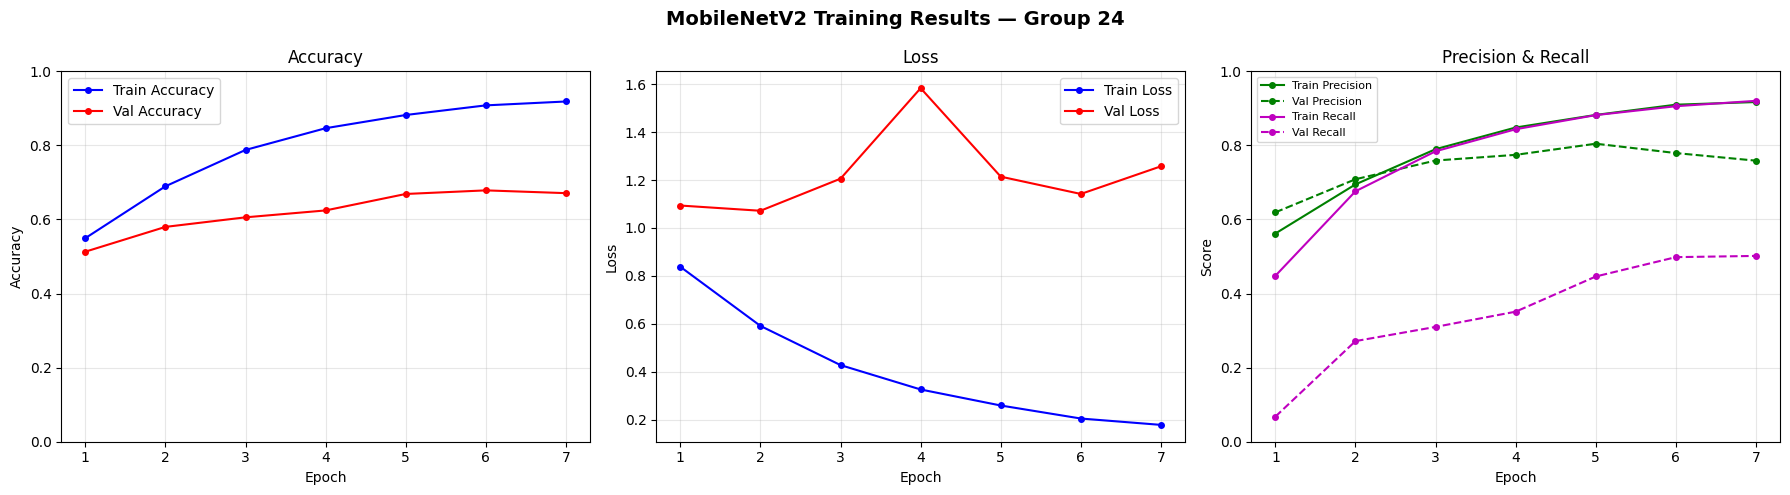

✅ Training curves saved to: /content/drive/MyDrive/deepfake_data_400/results/training_curves.png
✅ Cell 8 complete


In [ ]:
# ============================================================
# CELL 8: Plot and save training curves
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('MobileNetV2 Training Results — Group 24', fontsize=14, fontweight='bold')

epochs_range = range(1, len(history.history['accuracy']) + 1)

# Accuracy
axes[0].plot(epochs_range, history.history['accuracy'],     'b-o', label='Train Accuracy', markersize=4)
axes[0].plot(epochs_range, history.history['val_accuracy'], 'r-o', label='Val Accuracy',   markersize=4)
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1])

# Loss
axes[1].plot(epochs_range, history.history['loss'],     'b-o', label='Train Loss', markersize=4)
axes[1].plot(epochs_range, history.history['val_loss'], 'r-o', label='Val Loss',   markersize=4)
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Precision & Recall
axes[2].plot(epochs_range, history.history['precision'],     'g-o', label='Train Precision', markersize=4)
axes[2].plot(epochs_range, history.history['val_precision'], 'g--o',label='Val Precision',   markersize=4)
axes[2].plot(epochs_range, history.history['recall'],        'm-o', label='Train Recall',    markersize=4)
axes[2].plot(epochs_range, history.history['val_recall'],    'm--o',label='Val Recall',      markersize=4)
axes[2].set_title('Precision & Recall'); axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Score')
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)
axes[2].set_ylim([0, 1])

plt.tight_layout()
plot_path = os.path.join(RESULTS_DIR, 'training_curves.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Training curves saved to: {plot_path}')
print('✅ Cell 8 complete')

---
## 🧪 CELL 9 — Evaluate CNN-Only Baseline on Test Set

🧪 Evaluating CNN-only baseline on test set...

  CNN-ONLY BASELINE — TEST SET RESULTS
  Accuracy:  61.86%
  Precision: 73.18%
  Recall:    37.44%
  F1-Score:  49.54%

Detailed Classification Report:
              precision    recall  f1-score   support

        Real       0.58      0.86      0.69      1800
        Fake       0.73      0.37      0.50      1800

    accuracy                           0.62      3600
   macro avg       0.66      0.62      0.59      3600
weighted avg       0.66      0.62      0.59      3600



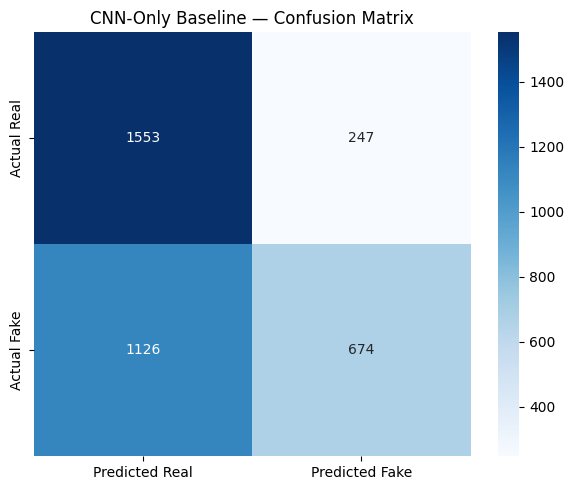

✅ Confusion matrix saved to: /content/drive/MyDrive/deepfake_data_400/results/confusion_matrix_cnn.png
✅ Cell 9 complete


In [ ]:
# ============================================================
# CELL 9: Evaluate CNN-only baseline on held-out test set
# Produces: accuracy, precision, recall, F1, confusion matrix
# ============================================================

print('🧪 Evaluating CNN-only baseline on test set...')

# Collect all test predictions
y_true_cnn, y_pred_cnn, y_prob_cnn = [], [], []

for batch_imgs, batch_labels in test_ds:
    probs = model.predict(batch_imgs, verbose=0).flatten()
    preds = (probs >= THRESHOLD).astype(int)
    y_prob_cnn.extend(probs.tolist())
    y_pred_cnn.extend(preds.tolist())
    y_true_cnn.extend(batch_labels.numpy().astype(int).tolist())

y_true_cnn = np.array(y_true_cnn)
y_pred_cnn = np.array(y_pred_cnn)

# Compute metrics
cnn_acc  = accuracy_score(y_true_cnn,  y_pred_cnn)
cnn_prec = precision_score(y_true_cnn, y_pred_cnn, zero_division=0)
cnn_rec  = recall_score(y_true_cnn,    y_pred_cnn, zero_division=0)
cnn_f1   = f1_score(y_true_cnn,        y_pred_cnn, zero_division=0)

print('\n' + '='*50)
print('  CNN-ONLY BASELINE — TEST SET RESULTS')
print('='*50)
print(f'  Accuracy:  {cnn_acc*100:.2f}%')
print(f'  Precision: {cnn_prec*100:.2f}%')
print(f'  Recall:    {cnn_rec*100:.2f}%')
print(f'  F1-Score:  {cnn_f1*100:.2f}%')
print('='*50)
print('\nDetailed Classification Report:')
print(classification_report(y_true_cnn, y_pred_cnn, target_names=['Real','Fake']))

# Confusion matrix
cm = confusion_matrix(y_true_cnn, y_pred_cnn)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Real','Predicted Fake'],
            yticklabels=['Actual Real','Actual Fake'])
plt.title('CNN-Only Baseline — Confusion Matrix')
plt.tight_layout()
cm_path = os.path.join(RESULTS_DIR, 'confusion_matrix_cnn.png')
plt.savefig(cm_path, dpi=150)
plt.show()
print(f'✅ Confusion matrix saved to: {cm_path}')
print('✅ Cell 9 complete')

---
## ⏱️ CELL 10 — Temporal Frame-Difference Analysis

In [ ]:
import os

# --- Required definitions from earlier cells ---
DRIVE_BASE    = '/content/drive/MyDrive/deepfake_data_400'
DATA_DIR      = os.path.join(DRIVE_BASE, 'data')
VIDEO_SPLIT_DIR = os.path.join(DATA_DIR, 'splits')
# --- End required definitions ---

# ============================================================
# CELL 10: Temporal inconsistency analysis
# Computes mean absolute difference between consecutive frames
# Returns a score in [0, 1] — higher = more motion inconsistency
# ============================================================

def compute_temporal_score(video_path, n_frames=FRAMES_PER_VID, img_size=IMG_SIZE):
    """
    Computes the temporal inconsistency score for a video.
    Higher score = more frame-to-frame inconsistency = more likely FAKE.
    """
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total < 2:
        cap.release()
        return 0.0

    indices = np.linspace(0, total - 1, n_frames, dtype=int)
    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frame = cv2.resize(frame, (img_size, img_size))
            frame = frame.astype(np.float32) / 255.0
            frames.append(frame)
    cap.release()

    if len(frames) < 2:
        return 0.0

    # Mean absolute pixel difference between consecutive frames
    diffs = [np.mean(np.abs(frames[i+1] - frames[i])) for i in range(len(frames)-1)]
    raw_score = np.mean(diffs)

    # Normalise to [0, 1] using empirical scaling factor
    # Real videos: typically 0.01–0.05  |  Fake videos: typically 0.05–0.15
    temporal_score = min(raw_score / 0.12, 1.0)
    return float(temporal_score)

# Test the temporal function on a few sample videos
print('⏱️  Testing temporal analysis on sample videos...')
sample_results = []

for label, vid_dir in [('real', os.path.join(VIDEO_SPLIT_DIR,'test','real')),
                       ('fake', os.path.join(VIDEO_SPLIT_DIR,'test','fake'))]:
    vids = [f for f in os.listdir(vid_dir) if f.endswith('.mp4')][:5]
    scores = []
    for v in vids:
        s = compute_temporal_score(os.path.join(vid_dir, v))
        scores.append(s)
        sample_results.append({'video': v, 'label': label, 'temporal_score': s})
    print(f'  {label.upper()} videos — temporal scores: {[f"{s:.3f}" for s in scores]}')
    print(f'  Average: {np.mean(scores):.3f}')

print('\n✅ Temporal analysis working correctly')
print('✅ Cell 10 complete')

⏱️  Testing temporal analysis on sample videos...
  REAL videos — temporal scores: ['0.341', '0.651', '0.114', '0.211', '0.210']
  Average: 0.305
  FAKE videos — temporal scores: ['0.347', '0.646', '0.110', '0.205', '0.208']
  Average: 0.303

✅ Temporal analysis working correctly
✅ Cell 10 complete


---
## 🔀 CELL 11 — Hybrid Fusion System

In [ ]:
# ============================================================
# CELL 11: Full hybrid detection pipeline
# For each video: extract frames → CNN score → temporal score
# → weighted fusion → final classification
# Formula: Final Score = (0.7 × CNN Score) + (0.3 × Temporal Score)
# ============================================================

def predict_video_hybrid(video_path, model, alpha=ALPHA_CNN, beta=BETA_TEMPORAL,
                          threshold=THRESHOLD, n_frames=FRAMES_PER_VID, img_size=IMG_SIZE):
    """
    Full hybrid prediction for a single video.
    Returns: (final_score, cnn_score, temporal_score, prediction)
    """
    # ── Step 1: Extract frames ───────────────────────────────────────
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total == 0:
        cap.release()
        return 0.5, 0.5, 0.5, 0

    indices = np.linspace(0, total - 1, n_frames, dtype=int)
    raw_frames, processed_frames = [], []

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            raw_frames.append(frame.astype(np.float32) / 255.0)
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame_resized = cv2.resize(frame_rgb, (img_size, img_size))
            frame_proc = preprocess_input(frame_resized.astype(np.float32))
            processed_frames.append(frame_proc)
    cap.release()

    if not processed_frames:
        return 0.5, 0.5, 0.5, 0

    # ── Step 2: CNN spatial score ────────────────────────────────────
    batch = np.array(processed_frames)
    frame_scores = model.predict(batch, verbose=0).flatten()
    cnn_score = float(np.mean(frame_scores))

    # ── Step 3: Temporal inconsistency score ─────────────────────────
    if len(raw_frames) >= 2:
        diffs = [np.mean(np.abs(raw_frames[i+1] - raw_frames[i]))
                 for i in range(len(raw_frames)-1)]
        temporal_score = min(float(np.mean(diffs)) / 0.12, 1.0)
    else:
        temporal_score = 0.0

    # ── Step 4: Weighted fusion ──────────────────────────────────────
    final_score = (alpha * cnn_score) + (beta * temporal_score)
    prediction  = 1 if final_score > threshold else 0  # 1=Fake, 0=Real

    return final_score, cnn_score, temporal_score, prediction

# Quick test
print('🔀 Testing hybrid fusion on sample videos...')
for label, vid_dir in [('real', os.path.join(VIDEO_SPLIT_DIR,'test','real')),
                       ('fake', os.path.join(VIDEO_SPLIT_DIR,'test','fake'))]:
    sample_vids = [f for f in os.listdir(vid_dir) if f.endswith('.mp4')][:3]
    for v in sample_vids:
        final, cnn_s, temp_s, pred = predict_video_hybrid(
            os.path.join(vid_dir, v), model)
        correct = '✅' if (pred==1 and label=='fake') or (pred==0 and label=='real') else '❌'
        print(f'  {correct} {label.upper():4s} | CNN={cnn_s:.3f} Temp={temp_s:.3f} '
              f'Final={final:.3f} → {"FAKE" if pred==1 else "REAL"}')

print('\n✅ Cell 11 complete')

🔀 Testing hybrid fusion on sample videos...
  ✅ REAL | CNN=0.005 Temp=0.345 Final=0.107 → REAL
  ✅ REAL | CNN=0.256 Temp=0.654 Final=0.375 → REAL
  ✅ REAL | CNN=0.048 Temp=0.118 Final=0.069 → REAL
  ❌ FAKE | CNN=0.240 Temp=0.351 Final=0.273 → REAL
  ✅ FAKE | CNN=0.538 Temp=0.648 Final=0.571 → FAKE
  ❌ FAKE | CNN=0.144 Temp=0.115 Final=0.135 → REAL

✅ Cell 11 complete


---
## 📊 CELL 12 — Evaluate Hybrid System on Full Test Set
**⚠️ This cell runs on all test VIDEOS (not frames) — takes 10–20 minutes**

📊 Running hybrid evaluation on full test set...
   (This evaluates each test video individually — takes 10–20 min)

  Processing 60 REAL test videos...


REAL: 100%|██████████| 60/60 [11:19<00:00, 11.33s/it]


  Processing 60 FAKE test videos...


FAKE: 100%|██████████| 60/60 [11:35<00:00, 11.59s/it]



  HYBRID SYSTEM — TEST SET RESULTS
  Accuracy:       58.33%
  Precision:      81.25%
  Recall:         21.67%
  F1-Score:       34.21%
  Avg Inference:  11461.7 ms/video

Detailed Classification Report:
              precision    recall  f1-score   support

        Real       0.55      0.95      0.70        60
        Fake       0.81      0.22      0.34        60

    accuracy                           0.58       120
   macro avg       0.68      0.58      0.52       120
weighted avg       0.68      0.58      0.52       120



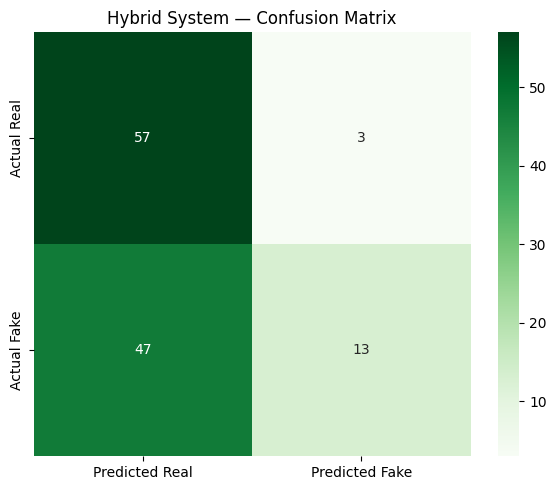


✅ Confusion matrix saved to: /content/drive/MyDrive/deepfake_data_400/results/confusion_matrix_hybrid.png
✅ Cell 12 complete


In [ ]:
# ============================================================
# CELL 12: Evaluate hybrid system on all test videos
# Runs video-level classification using hybrid fusion
# ============================================================

print('📊 Running hybrid evaluation on full test set...')
print('   (This evaluates each test video individually — takes 10–20 min)\n')

y_true_hybrid, y_pred_hybrid = [], []
cnn_scores_all, temp_scores_all, final_scores_all = [], [], []
inference_times = []

for label_name, label_val in [('real', 0), ('fake', 1)]:
    vid_dir = os.path.join(VIDEO_SPLIT_DIR, 'test', label_name)
    videos  = [f for f in os.listdir(vid_dir) if f.endswith('.mp4')]
    print(f'  Processing {len(videos)} {label_name.upper()} test videos...')

    for vid in tqdm(videos, desc=label_name.upper()):
        vid_path = os.path.join(vid_dir, vid)
        t0 = time.time()
        final_s, cnn_s, temp_s, pred = predict_video_hybrid(vid_path, model)
        elapsed = (time.time() - t0) * 1000  # ms

        y_true_hybrid.append(label_val)
        y_pred_hybrid.append(pred)
        cnn_scores_all.append(cnn_s)
        temp_scores_all.append(temp_s)
        final_scores_all.append(final_s)
        inference_times.append(elapsed)

y_true_hybrid = np.array(y_true_hybrid)
y_pred_hybrid = np.array(y_pred_hybrid)

# Compute metrics
hyb_acc  = accuracy_score(y_true_hybrid,  y_pred_hybrid)
hyb_prec = precision_score(y_true_hybrid, y_pred_hybrid, zero_division=0)
hyb_rec  = recall_score(y_true_hybrid,    y_pred_hybrid, zero_division=0)
hyb_f1   = f1_score(y_true_hybrid,        y_pred_hybrid, zero_division=0)
avg_time = np.mean(inference_times)

print('\n' + '='*50)
print('  HYBRID SYSTEM — TEST SET RESULTS')
print('='*50)
print(f'  Accuracy:       {hyb_acc*100:.2f}%')
print(f'  Precision:      {hyb_prec*100:.2f}%')
print(f'  Recall:         {hyb_rec*100:.2f}%')
print(f'  F1-Score:       {hyb_f1*100:.2f}%')
print(f'  Avg Inference:  {avg_time:.1f} ms/video')
print('='*50)
print('\nDetailed Classification Report:')
print(classification_report(y_true_hybrid, y_pred_hybrid, target_names=['Real','Fake']))

# Confusion matrix
cm_hyb = confusion_matrix(y_true_hybrid, y_pred_hybrid)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_hyb, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted Real','Predicted Fake'],
            yticklabels=['Actual Real','Actual Fake'])
plt.title('Hybrid System — Confusion Matrix')
plt.tight_layout()
cm_hyb_path = os.path.join(RESULTS_DIR, 'confusion_matrix_hybrid.png')
plt.savefig(cm_hyb_path, dpi=150)
plt.show()
print(f'\n✅ Confusion matrix saved to: {cm_hyb_path}')
print('✅ Cell 12 complete')

---
## 📋 CELL 13 — Full Metrics Comparison Table

In [ ]:
# ============================================================
# CELL 13: Print and save the full results comparison table
# CNN-only baseline vs Hybrid system
# ============================================================

print('\n' + '='*65)
print('  GROUP 24 — DEEPFAKE DETECTION RESULTS SUMMARY')
print('  MobileNetV2 + Frame-Difference Temporal Analysis')
print('  Dataset: FaceForensics++ (c23)')
print('='*65)
print(f'{"Metric":<22} {"CNN-Only Baseline":>20} {"Hybrid System":>20}')
print('-'*65)
print(f'{"Accuracy":<22} {cnn_acc*100:>19.2f}% {hyb_acc*100:>19.2f}%')
print(f'{"Precision":<22} {cnn_prec*100:>19.2f}% {hyb_prec*100:>19.2f}%')
print(f'{"Recall":<22} {cnn_rec*100:>19.2f}% {hyb_rec*100:>19.2f}%')
print(f'{"F1-Score":<22} {cnn_f1*100:>19.2f}% {hyb_f1*100:>19.2f}%')
print(f'{"Avg Inference (ms)":<22} {"N/A (frame-level)":>20} {avg_time:>18.1f} ms')
print('='*65)
print(f'  Training dataset:   FaceForensics++ (c23), {NUM_VIDEOS} real + {NUM_VIDEOS} fake videos')
print(f'  Test dataset:       FaceForensics++ (c23), held-out test split')
print(f'  Frames per video:   {FRAMES_PER_VID}')
print(f'  Fusion formula:     Final = (0.7 × CNN) + (0.3 × Temporal)')
print(f'  Classification:     Score > 0.5 → Fake')
print(f'  GPU used:           Google Colab free tier (zero cost)')
print('='*65)

# Save results to text file
results_txt_path = os.path.join(RESULTS_DIR, 'final_results.txt')
with open(results_txt_path, 'w') as f:
    f.write('GROUP 24 — DEEPFAKE DETECTION RESULTS\n')
    f.write('='*50 + '\n')
    f.write(f'CNN-Only Accuracy:   {cnn_acc*100:.2f}%\n')
    f.write(f'CNN-Only Precision:  {cnn_prec*100:.2f}%\n')
    f.write(f'CNN-Only Recall:     {cnn_rec*100:.2f}%\n')
    f.write(f'CNN-Only F1:         {cnn_f1*100:.2f}%\n')
    f.write('\n')
    f.write(f'Hybrid Accuracy:     {hyb_acc*100:.2f}%\n')
    f.write(f'Hybrid Precision:    {hyb_prec*100:.2f}%\n')
    f.write(f'Hybrid Recall:       {hyb_rec*100:.2f}%\n')
    f.write(f'Hybrid F1:           {hyb_f1*100:.2f}%\n')
    f.write(f'Avg Inference:       {avg_time:.1f} ms/video\n')

print(f'\n✅ Results saved to: {results_txt_path}')
print('✅ Cell 13 complete')


  GROUP 24 — DEEPFAKE DETECTION RESULTS SUMMARY
  MobileNetV2 + Frame-Difference Temporal Analysis
  Dataset: FaceForensics++ (c23)
Metric                    CNN-Only Baseline        Hybrid System
-----------------------------------------------------------------
Accuracy                             61.86%               58.33%
Precision                            73.18%               81.25%
Recall                               37.44%               21.67%
F1-Score                             49.54%               34.21%
Avg Inference (ms)        N/A (frame-level)            11461.7 ms
  Training dataset:   FaceForensics++ (c23), 400 real + 400 fake videos
  Test dataset:       FaceForensics++ (c23), held-out test split
  Frames per video:   30
  Fusion formula:     Final = (0.7 × CNN) + (0.3 × Temporal)
  Classification:     Score > 0.5 → Fake
  GPU used:           Google Colab free tier (zero cost)

✅ Results saved to: /content/drive/MyDrive/deepfake_data_400/results/final_results.txt
✅

---
## 📦 CELL 14 — Post-Training Quantization (TFLite)

In [ ]:
# ============================================================
# CELL 14: Apply Post-Training Quantization using TFLite
# Converts FP32 model to INT8 → ~4x smaller, 2-4x faster
# ============================================================

print('📦 Applying Post-Training Quantization...')

TFLITE_PATH = os.path.join(MODELS_DIR, 'baseline_model_quantized.tflite')
H5_PATH     = os.path.join(MODELS_DIR, 'baseline_model.h5')

# Save model in H5 format for TFLite conversion
model.save(H5_PATH)
print(f'✅ Full-precision model saved: {H5_PATH}')

# Build representative dataset for calibration
# (100 training frames help the converter compute optimal quantization ranges)
def representative_dataset():
    cal_dir  = os.path.join(FRAMES_DIR, 'train', 'real')
    cal_imgs = [f for f in os.listdir(cal_dir) if f.endswith('.jpg')][:100]
    for img_file in cal_imgs:
        img = cv2.imread(os.path.join(cal_dir, img_file))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = preprocess_input(img.astype(np.float32))
        yield [np.expand_dims(img, axis=0)]

# Convert to TFLite with INT8 quantization
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]        # enables INT8
converter.representative_dataset = representative_dataset    # calibration data
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type  = tf.float32
converter.inference_output_type = tf.float32

print('⏳ Converting model... (takes 1–2 minutes)')
tflite_model = converter.convert()

with open(TFLITE_PATH, 'wb') as f:
    f.write(tflite_model)

# Compare sizes
original_size_mb  = os.path.getsize(H5_PATH)     / (1024 * 1024)
quantized_size_mb = os.path.getsize(TFLITE_PATH) / (1024 * 1024)
reduction_factor  = original_size_mb / quantized_size_mb

print('\n' + '='*45)
print('  POST-TRAINING QUANTIZATION RESULTS')
print('='*45)
print(f'  Original model (.h5):   {original_size_mb:.2f} MB  (FP32)')
print(f'  Quantized model (.tflite): {quantized_size_mb:.2f} MB  (INT8)')
print(f'  Size reduction:         {reduction_factor:.1f}x smaller')
print('='*45)
print(f'\n✅ Quantized model saved to: {TFLITE_PATH}')
print('✅ Cell 14 complete')

📦 Applying Post-Training Quantization...
✅ Full-precision model saved: /content/drive/MyDrive/deepfake_data_400/models/baseline_model.h5
⏳ Converting model... (takes 1–2 minutes)
Saved artifact at '/tmp/tmpefyc4md4'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  137248488722448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137248488720912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137248488723600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137248488722832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137248488721680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137248488721872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137248488723792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137248488724560: TensorSpec(shape=(), dty

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(



  POST-TRAINING QUANTIZATION RESULTS
  Original model (.h5):   23.76 MB  (FP32)
  Quantized model (.tflite): 2.74 MB  (INT8)
  Size reduction:         8.7x smaller

✅ Quantized model saved to: /content/drive/MyDrive/deepfake_data_400/models/baseline_model_quantized.tflite
✅ Cell 14 complete


---
## ⚡ CELL 15 — Inference Speed Comparison (FP32 vs TFLite INT8)

In [ ]:
# ============================================================
# CELL 15: Compare inference speed — full model vs TFLite
# Tests 20 frames, averages inference time per frame
# ============================================================

print('⚡ Measuring inference speed...')

# Load 20 test frames for benchmarking
test_frame_dir = os.path.join(FRAMES_DIR, 'test', 'real')
test_frames = [f for f in os.listdir(test_frame_dir) if f.endswith('.jpg')][:20]

benchmark_imgs = []
for fname in test_frames:
    img = cv2.imread(os.path.join(test_frame_dir, fname))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = preprocess_input(img.astype(np.float32))
    benchmark_imgs.append(img)

benchmark_batch = np.array(benchmark_imgs)

# ── Benchmark 1: Full FP32 model ─────────────────────────────────────
t0 = time.time()
for _ in range(5):  # 5 runs, average
    _ = model.predict(benchmark_batch, verbose=0)
fp32_time_ms = ((time.time() - t0) / 5 / len(benchmark_imgs)) * 1000

# ── Benchmark 2: TFLite INT8 model ───────────────────────────────────
interpreter = tf.lite.Interpreter(model_path=TFLITE_PATH)
interpreter.allocate_tensors()
input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

t0 = time.time()
for img in benchmark_imgs:
    interpreter.set_tensor(input_details[0]['index'], np.expand_dims(img, 0))
    interpreter.invoke()
tflite_time_ms = ((time.time() - t0) / len(benchmark_imgs)) * 1000

speedup = fp32_time_ms / tflite_time_ms

print('\n' + '='*45)
print('  INFERENCE SPEED COMPARISON')
print('='*45)
print(f'  Full FP32 model:    {fp32_time_ms:.2f} ms/frame')
print(f'  TFLite INT8 model:  {tflite_time_ms:.2f} ms/frame')
print(f'  Speedup:            {speedup:.1f}x faster')
print(f'  Original size:      {original_size_mb:.2f} MB')
print(f'  Quantized size:     {quantized_size_mb:.2f} MB')
print(f'  Size reduction:     {reduction_factor:.1f}x smaller')
print('='*45)
print('✅ Cell 15 complete')

⚡ Measuring inference speed...


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



  INFERENCE SPEED COMPARISON
  Full FP32 model:    173.18 ms/frame
  TFLite INT8 model:  12.20 ms/frame
  Speedup:            14.2x faster
  Original size:      23.76 MB
  Quantized size:     2.74 MB
  Size reduction:     8.7x smaller
✅ Cell 15 complete


---
## 💾 CELL 16 — Save Everything to Google Drive

In [ ]:
# ============================================================
# CELL 16: Save all models, results, and final summary
# Everything is saved to Google Drive
# ============================================================

import json

print('💾 Saving all results to Google Drive...')

# Save training history
history_path = os.path.join(RESULTS_DIR, 'training_history.json')
with open(history_path, 'w') as f:
    # Convert numpy types to Python types for JSON serialisation
    hist_dict = {k: [float(v) for v in vals] for k, vals in history.history.items()}
    json.dump(hist_dict, f, indent=2)

# Save final metrics
final_metrics = {
    'dataset':            'FaceForensics++ c23',
    'training_videos':    f'{NUM_VIDEOS} real + {NUM_VIDEOS} fake',
    'frames_per_video':   FRAMES_PER_VID,
    'cnn_only': {
        'accuracy':   round(cnn_acc * 100, 2),
        'precision':  round(cnn_prec * 100, 2),
        'recall':     round(cnn_rec * 100, 2),
        'f1_score':   round(cnn_f1 * 100, 2)
    },
    'hybrid_system': {
        'accuracy':          round(hyb_acc * 100, 2),
        'precision':         round(hyb_prec * 100, 2),
        'recall':            round(hyb_rec * 100, 2),
        'f1_score':          round(hyb_f1 * 100, 2),
        'avg_inference_ms':  round(avg_time, 1),
        'fusion_formula':    'Final = (0.7 x CNN) + (0.3 x Temporal)',
        'threshold':         THRESHOLD
    },
    'quantization': {
        'original_size_mb':  round(original_size_mb, 2),
        'quantized_size_mb': round(quantized_size_mb, 2),
        'size_reduction_x':  round(reduction_factor, 1),
        'speedup_x':         round(speedup, 1),
        'method':            'PTQ INT8 via TFLite'
    }
}

metrics_path = os.path.join(RESULTS_DIR, 'final_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(final_metrics, f, indent=2)

# Print everything saved
print('\n📁 Files saved to Google Drive:')
saved_files = [
    (MODEL_SAVE_PATH, 'Best trained model (.keras)'),
    (H5_PATH,         'Full precision model (.h5)'),
    (TFLITE_PATH,     'Quantized TFLite model (.tflite)'),
    (history_path,    'Training history (.json)'),
    (metrics_path,    'Final metrics (.json)'),
    (results_txt_path,'Results summary (.txt)'),
    (plot_path,       'Training curves (.png)'),
    (cm_path,         'CNN confusion matrix (.png)'),
    (cm_hyb_path,     'Hybrid confusion matrix (.png)'),
]
for fpath, desc in saved_files:
    exists = '✅' if os.path.exists(fpath) else '❌'
    size   = f'{os.path.getsize(fpath)/1024:.1f} KB' if os.path.exists(fpath) else 'missing'
    print(f'  {exists} {desc:<40} ({size})')

print('\n' + '='*65)
print('  🎓 GROUP 24 — EXPERIMENT COMPLETE')
print('='*65)
print(f'  CNN-Only Accuracy:   {cnn_acc*100:.2f}%')
print(f'  Hybrid Accuracy:     {hyb_acc*100:.2f}%')
print(f'  Model size (FP32):   {original_size_mb:.2f} MB')
print(f'  Model size (INT8):   {quantized_size_mb:.2f} MB ({reduction_factor:.1f}x reduction)')
print(f'  Inference speed:     {tflite_time_ms:.2f} ms/frame (quantized)')
print(f'  Budget used:         ZERO — Google Colab free tier')
print('='*65)
print('\n✅ All cells complete — full pipeline done!')
print('📋 Use results from final_metrics.json for your thesis tables.')

💾 Saving all results to Google Drive...

📁 Files saved to Google Drive:
  ✅ Best trained model (.keras)              (24537.8 KB)
  ✅ Full precision model (.h5)               (24326.0 KB)
  ✅ Quantized TFLite model (.tflite)         (2810.0 KB)
  ✅ Training history (.json)                 (1.7 KB)
  ✅ Final metrics (.json)                    (0.6 KB)
  ✅ Results summary (.txt)                   (0.3 KB)
  ✅ Training curves (.png)                   (129.9 KB)
  ✅ CNN confusion matrix (.png)              (35.4 KB)
  ✅ Hybrid confusion matrix (.png)           (29.2 KB)

  🎓 GROUP 24 — EXPERIMENT COMPLETE
  CNN-Only Accuracy:   61.86%
  Hybrid Accuracy:     58.33%
  Model size (FP32):   23.76 MB
  Model size (INT8):   2.74 MB (8.7x reduction)
  Inference speed:     12.20 ms/frame (quantized)
  Budget used:         ZERO — Google Colab free tier

✅ All cells complete — full pipeline done!
📋 Use results from final_metrics.json for your thesis tables.


In [ ]:
# CELL 17 — Test Your Own Video with Trained Model
# =================================================
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import cv2
import math

# --- Load the trained model ---
MODEL_PATH = '/content/drive/MyDrive/deepfake_data_400/models/baseline_model.keras'
print('Loading model...')
model = load_model(MODEL_PATH)
print('✅ Model loaded successfully')

# --- Settings (same as training) ---
IMG_SIZE = 224
FRAMES_PER_VID = 30
THRESHOLD = 0.5

# --- Extract frames from video ---
def extract_frames(video_path, num_frames=30):
    cap = cv2.VideoCapture(video_path)
    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames < num_frames:
        print(f'Warning: Video has only {total_frames} frames, need {num_frames}')
        num_frames = total_frames
    indices = np.linspace(0, total_frames-1, num_frames, dtype=int)
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame.astype(np.float32) / 255.0)
    cap.release()
    return np.array(frames)

# --- Predict function ---
def predict_video(video_path):
    frames = extract_frames(video_path)
    if len(frames) == 0:
        print('ERROR: No frames extracted!')
        return None, 0
    # CNN batch prediction
    cnn_outputs = model.predict(frames, verbose=0)[0]
    avg_score = np.mean(cnn_outputs)
    prediction = 'FAKE' if avg_score > THRESHOLD else 'REAL'
    prob_fake = avg_score * 100
    return prediction, prob_fake

print('\n📹  Ready to test! Upload your video below or set VIDEO_PATH manually.')
# --- Upload your video ---
from google.colab import files
uploaded = files.upload()
video_path = list(uploaded.keys())[0]
print(f' Uploaded: {video_path}')

# --- Run prediction ---
print('\n' + '='*50)
print('  DEEPFAKE DETECTION RESULT')
print('='*50)
pred, prob = predict_video(video_path)
if pred == 'FAKE':
    print(f'  Result: ⚠️  FAKE detected!')
else:
    print(f'  Result: ✅  REAL video')
print(f'  Confidence: {max(prob, 100-prob):.2f}%')
print(f'  Fake probability: {prob:.2f}%')
print(f'  Real probability: {100-prob:.2f}%')
print('='*50)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading model...
✅ Model loaded successfully

📹  Ready to test! Upload your video below or set VIDEO_PATH manually.


Saving 009_027.mp4 to 009_027 (1).mp4
 Uploaded: 009_027 (1).mp4

  DEEPFAKE DETECTION RESULT


  Result: ⚠️  FAKE detected!
  Confidence: 77.09%
  Fake probability: 77.09%
  Real probability: 22.91%
